## Analysis of synthetic data ratios

#### Collecting all metrics in one file to find best synth to in-domain ratio

In [1]:
import os
import sys

# move to project root
os.chdir("..")

# ensure project root is importable
sys.path.append(os.getcwd())

In [2]:
import os
import json
from glob import glob

INPUT_DIR = "results/data_augmentation/"   # change this
OUTPUT_FILE = "results/data_augmentation/metrics_all_ratios.json"

results = []

json_files = glob(os.path.join(INPUT_DIR, "results_mixed_*.json"))

for filepath in json_files:
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    seqeval = data.get("seqeval", {})
    span_metrics = data.get("span_metrics", {})

    f1_scores = {}

    # entity-level F1
    for label, metrics in seqeval.items():
        if isinstance(metrics, dict) and "f1" in metrics:
            f1_scores[label] = metrics["f1"]

    # span-level F1 (merged into same dict)
    for label, metrics in span_metrics.items():
        if isinstance(metrics, dict) and "f1" in metrics:
            f1_scores[label] = metrics["f1"]

    results.append({
        "file": os.path.basename(filepath),
        "f1": f1_scores
    })

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

print(f"Saved {len(results)} files → {OUTPUT_FILE}")

Saved 6 files → results/data_augmentation/metrics_all_ratios.json


#### Checking increasing number of sentences in mixed datasets

In [8]:
from util.preprocessing import parse_iob2_file

# List of file paths
file_paths = [
    "data/FIN5_fixed.txt",
    "data/mixed_4.txt",
    "data/mixed_6.txt",
    "data/mixed_9.txt"
]

# Count sentences in each file
for file_path in file_paths:
    sentences, _ = parse_iob2_file(file_path)
    print(f"{file_path}: {len(sentences)} sentences")

data/FIN5_fixed.txt: 1169 sentences
data/mixed_4.txt: 1772 sentences
data/mixed_6.txt: 2015 sentences
data/mixed_9.txt: 2451 sentences


### Learning curve (Span F1)

In [10]:
import pandas as pd
df = pd.read_csv("results/data_augmentation/f1_wide_table.csv")
df = df[["sentences", "f1_train_exact", "f1_test_exact"]]
display(df)

,sentences,f1_train_exact,f1_test_exact
0,1169,0.984925,0.759152
1,1772,0.990361,0.776923
2,2015,0.990094,0.807921
3,2451,0.992980,0.782274


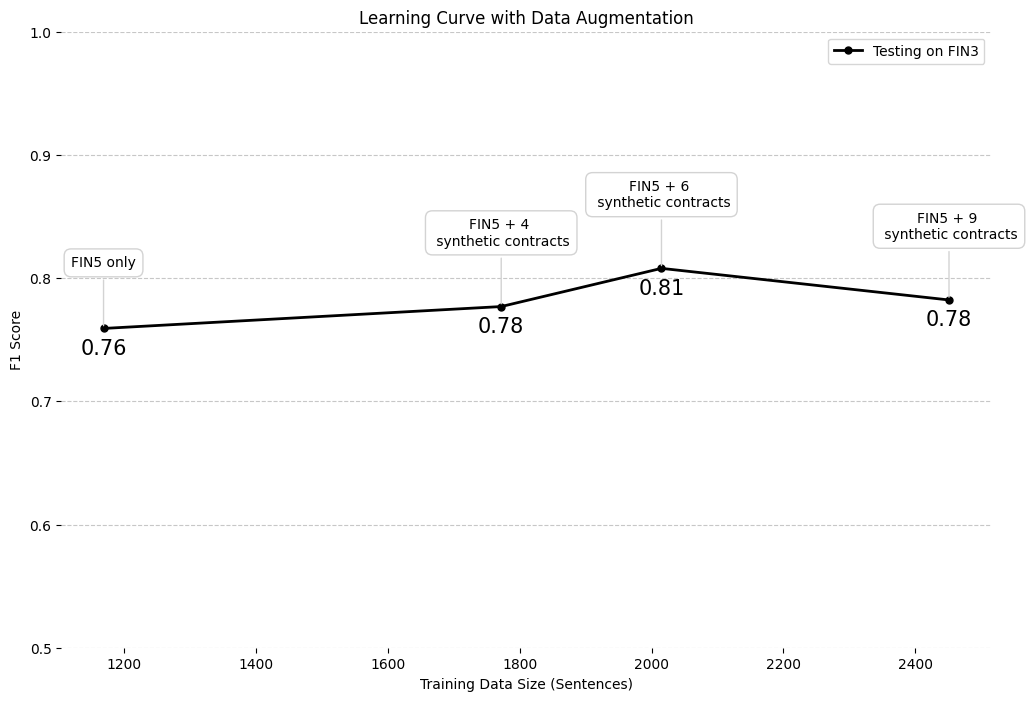

In [11]:
import matplotlib.pyplot as plt

# Plot learning curve
plt.figure(figsize=(12, 8))  # Adjusted figure size for better visibility

# Plot testing F1 scores (FIN3)
plt.plot(df['sentences'], df['f1_test_exact'], label='Testing on FIN3', color='black', marker='o', linewidth=2, markersize=5)

# Add labels, title, and legend
plt.xlabel('Training Data Size (Sentences)')
plt.ylabel('F1 Score')
plt.title('Learning Curve with Data Augmentation')
plt.legend()

# Add text annotations as message bubbles pointing to dots
annotations = ['FIN5 only', 'FIN5 + 4 \n synthetic contracts', 'FIN5 + 6 \n synthetic contracts', 'FIN5 + 9 \n synthetic contracts']
for x, y, label in zip(df['sentences'], df['f1_test_exact'], annotations):
    plt.annotate(
        label, 
        xy=(x, y), 
        xytext=(x, y + 0.05),  # Position text slightly above the dot
        fontsize=10,
        color='black', 
        ha='center', 
        bbox=dict(facecolor='white', edgecolor='lightgrey', boxstyle='round,pad=0.5'),
        arrowprops=dict(arrowstyle='-', color='lightgrey')  # Add line pointing to the dot
    )

# Add numbers below the dots
for x, y in zip(df['sentences'], df['f1_test_exact']):
    plt.text(x, y - 0.008, f'{y:.2f}', fontsize=15, ha='center', va='top')

# Remove axis lines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

# Add horizontal grid lines only
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust y-axis limits for better zoom-out
plt.ylim(0.5, 1.0)
plt.rcParams.update({'font.size': 16})  # Set the global font size to 14

# Show the plot
plt.show()